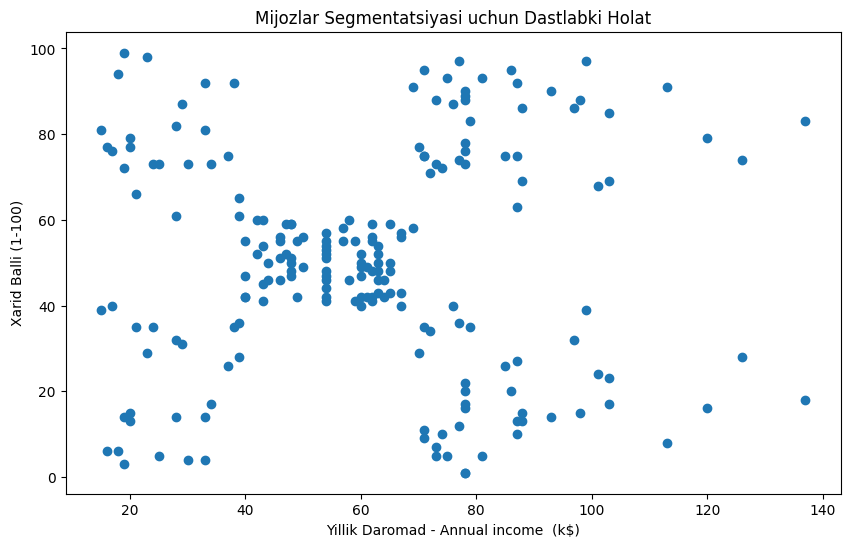

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('data.csv')
plt.figure(figsize=(10, 6))
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])
plt.xlabel('Yillik Daromad - Annual income  (k$)')
plt.ylabel('Xarid Balli - Spending Score (1-100)')
plt.title('Mijozlar Segmentatsiyasi uchun Dastlabki Holat - Initial Situation for Customer Segmentation')
plt.show()
data.head()

Datani vizual ko'rinishi scatter bilan 

Data visualization using scatter plots.

In [8]:
print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Bo'sh kataklar yo'q demak uni to'ldirish uchun turli KNN imputer yoki mean, median kerak emas

There are no missing values, so imputation methods like KNN Imputer, mean, or median are not required.

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


Datani String qiymatli ustunlarni songa o'tkazdim

I converted categorical (string) columns into numerical values.

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


Datani Standard Scaler bilan normallashtirdim . Sababi agar 100 va 2 sonlar bo'lsa bu sonlarni algorithm uchun 100 , 2 dan qaraganda ko'proq ustun ko'yadi

I normalized the data using StandardScaler.This is because algorithms might give more weight to larger values (like 100) compared to smaller ones (like 2) if the data is not scaled.

In [17]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data) # Normallashgan ma'lumotni ishlatamiz
    wcss.append(kmeans.inertia_)
print(wcss)

[600.0, 389.3861889564371, 295.45624492135573, 205.22514747675922, 169.89149793438588, 134.3527747740149, 121.38935022502872, 113.72723000071333, 102.1362384432925, 92.55027231838781]


WCSS (Within-Cluster Sum of Squares)

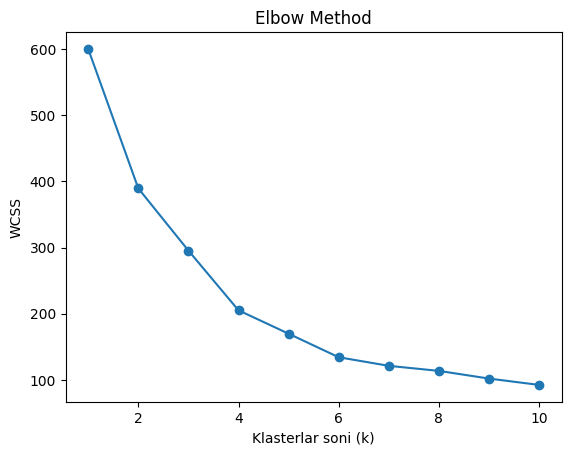

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Klasterlar soni (k) Clastur\'s number ')
plt.ylabel('WCSS')
plt.show()

Find Elbow

In [ ]:
# Optimal k=5 deb tanladik
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
# Mijozlarni guruhlarga ajratamiz
y_kmeans = kmeans.fit_predict(scaled_data)
# Natijani asosiy jadvalga yangi ustun qilib qo'shamiz
data['Cluster'] = y_kmeans
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,2
1,2,1,21,15,81,2
2,3,0,20,16,6,3
3,4,0,23,16,77,2
4,5,0,31,17,40,2


Datani umumiy ko'rinishi

General overview of the dataset.

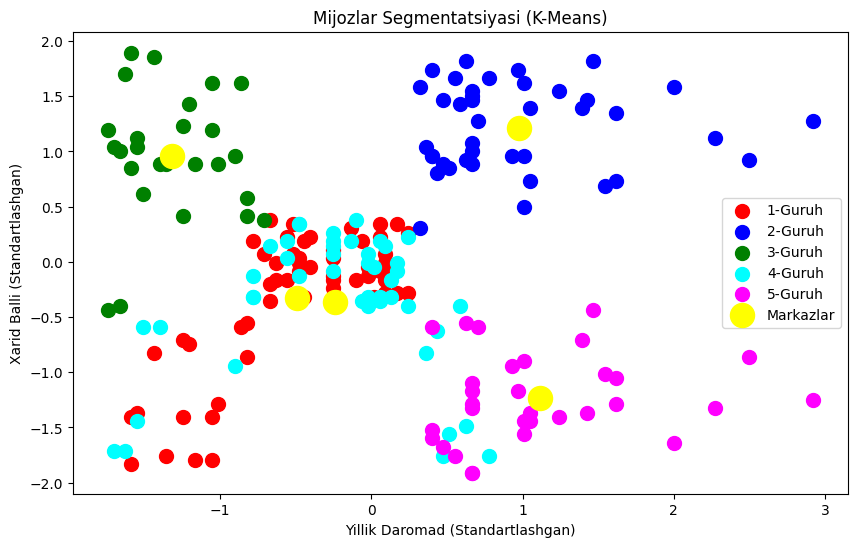

In [ ]:
# Har bir klasterni alohida rangda chizamiz
plt.figure(figsize=(10, 6))

# data[y_kmeans == 0, 0] — bu 0-klasterga tegishli mijozlarning 1-ustun (daromad) qiymatlari
plt.scatter(scaled_data[y_kmeans == 0, 1], scaled_data[y_kmeans == 0, 2], s=100, c='red', label='1-Guruh')
plt.scatter(scaled_data[y_kmeans == 1, 1], scaled_data[y_kmeans == 1, 2], s=100, c='blue', label='2-Guruh')
plt.scatter(scaled_data[y_kmeans == 2, 1], scaled_data[y_kmeans == 2, 2], s=100, c='green', label='3-Guruh')
plt.scatter(scaled_data[y_kmeans == 3, 1], scaled_data[y_kmeans == 3, 2], s=100, c='cyan', label='4-Guruh')
plt.scatter(scaled_data[y_kmeans == 4, 1], scaled_data[y_kmeans == 4, 2], s=100, c='magenta', label='5-Guruh')

# Klaster markazlarini (centroids) belgilaymiz
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=300, c='yellow', label='Markazlar')

plt.title('Customer Segmentation')
plt.xlabel('Yillik Daromad (Standartlashgan) - Annual income')
plt.ylabel('Xarid Balli (Standartlashgan) - Speding score')
plt.legend()
plt.show()

Mijozlarni Segmentatsiyasi

Customer Segmentation.